In [1]:
from typing import Dict,TypedDict,List
from langgraph.graph import StateGraph,START,END
import random

In [3]:
class AgentState(TypedDict):
    name: str
    guesses:List[int]
    attempts: int
    lower_bound: int
    upper_bound: int
    secret_number: int
    hint: str #correct,higher,lower

In [18]:
def setup(state: AgentState) -> AgentState:
    
    """setup node which say hi to person"""
    state['name']=f"Hi there,{state['name']}!  "
    state['attempts']=0
    return state
def guess_node(state: AgentState) -> AgentState:
 
    """Random node which generate a random number and add it to state"""
    h=state['upper_bound']
    l=state['lower_bound']
    num = random.randint(l, h)
    state['guesses'].append(num)
    state['attempts']+=1
    return state

def should_continue(state:AgentState) -> AgentState:
   
    """Condition node which check if attempts is less than 7"""
    if state['secret_number'] in state['guesses'] and state['attempts']<=7:

        state['hint']="correct"
        return "end" #exit loop 
    elif state['attempts']>7:

        state['hint']="out of attempts"
        return "end" #exit loop
    else:

        if state['guesses'][-1] > state['secret_number']:
            state['hint']="lower"
            state['upper_bound']=min(state['guesses'][-1]-1,state['upper_bound'])
        elif state['guesses'][-1] < state['secret_number']:
            state['hint']="higher"
            state['lower_bound']=max(state['guesses'][-1]+1,state['lower_bound'])
        print(f"Attempt {state['attempts']}: Guess={state['guesses'][-1]}, Hint={state['hint']}, Lower Bound={state['lower_bound']}, Upper Bound={state['upper_bound']}")
    return "loop"

In [19]:
graph=StateGraph(AgentState)


graph.add_node("setup_node",setup)
graph.add_node("guess_node",guess_node)
graph.add_edge("setup_node","guess_node")

graph.add_conditional_edges(
    "guess_node",
    should_continue,
    {
        "loop": "guess_node",
        "end": END
    },
    
)

graph.set_entry_point("setup_node")

app=graph.compile()

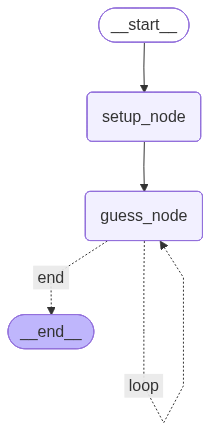

In [6]:
from  IPython.display import display,Image
display(Image(app.get_graph().draw_mermaid_png()))

In [20]:
app.invoke({
    "name":"Student","guesses":[],"attempts":-1,"lower_bound":1,"upper_bound":20,"secret_number":7,"hint":""
    })

Attempt 1: Guess=18, Hint=lower, Lower Bound=1, Upper Bound=17
Attempt 2: Guess=14, Hint=lower, Lower Bound=1, Upper Bound=13
Attempt 3: Guess=11, Hint=lower, Lower Bound=1, Upper Bound=10
Attempt 4: Guess=11, Hint=lower, Lower Bound=1, Upper Bound=10
Attempt 5: Guess=9, Hint=lower, Lower Bound=1, Upper Bound=8


{'name': 'Hi there,Student!  ',
 'guesses': [18, 14, 11, 11, 9, 7],
 'attempts': 6,
 'lower_bound': 1,
 'upper_bound': 20,
 'secret_number': 7,
 'hint': ''}